In [2]:
from sklearn.datasets import make_regression 
import numpy as np 
import torch
from sklearn.model_selection import train_test_split
import random

In [3]:
import torch

# this is single feature dataset
x, y = make_regression(
    n_samples=100,
    n_features=2,
    noise=20,
    random_state=42
)

# make_regression returns numpy arrays -> convert to torch tensors
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# starting guess for the line: y = w*x + b
w1 = torch.tensor(2.0)
w2 = torch.tensor(4.0)   # weight (slope)

b = torch.tensor(5.0)   # bias  (intercept)

print(x.shape)
print(y.shape)

torch.Size([100, 2])
torch.Size([100])


In [4]:
def SGD(Loss, W1, W2, B, X_W1, X_W2):
    """ 
    For MSE, the gradient would be 
    Loss = (y_pred - y_train) ^2 
    Loss = ( w1 . x_w1 + w2 . x_w2 + b - y_train) ^2 

    With Respect to Weight 1: 
    ∂Loss / ∂w1 = 2 (w1 . x_w1 + w2 . x_w2 + b - y_train) * x_w1

    With Respect to Weight 2: 
    ∂Loss / ∂w1 = 2 (w1 . x_w1 + w2 . x_w2 + b - y_train) * x_w2
    
    With Respect to Bias: 
    ∂Loss / ∂b = 2 (w1 . x_w1 + w2 . x_w2 + b - y_train) * 1

    Therefore: 
    grad_w1 = 2 (loss) * x_w1
    grad_w2 = 2 (loss) * x_w2 
    grad_b = 2 (loss) * 1 
    
    """

    lr = 0.01 

    grad_W1 = 2 * (Loss) * X_W1
    grad_W2 = 2 * (Loss) * X_W2
    grad_B = 2 * (Loss) * 1

    W1_new = W1 - lr * grad_W1
    W2_new = W2 - lr * grad_W2
    B_new = B - lr * grad_B

    return W1_new, W2_new, B_new

y = y.reshape(100,1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)
loss_indx = []

for i in range(100):

    k = random.randint(1, len(x_train)-1)

    x_batch = x_train[k]
    y_batch = y_train[k]

    y_pred = w1 * x_batch[0] + w2 * x_batch[1] + b

    # signed residual feeds the gradient
    loss = y_pred - y_batch

    # save the SQUARED loss as a plain number so we can plot it per step
    loss_indx.append((loss ** 2).item())

    new_w1, new_w2, new_b = SGD(loss, w1, w2, b, x_batch[0], x_batch[1])

    w1 = new_w1
    w2 = new_w2
    b = new_b 


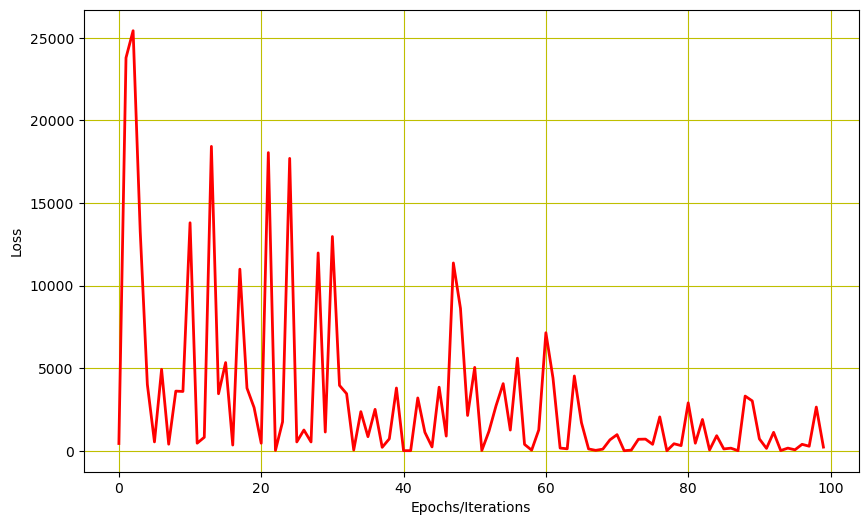

In [5]:
# loss_indx holds the squared loss at each SGD step (filled in the loop above)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_indx, 'r', lw=2)
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.grid(True, color='y')
plt.show()

In [6]:
# sanity check: compare my SGD to sklearn's SGDRegressor
from sklearn.linear_model import SGDRegressor

# penalty=None -> plain SGD, no regularization (matches my version)
ref = SGDRegressor(penalty=None).fit(x.numpy(), y.numpy().ravel())

print(f"my SGD:   w1={w1.item():.2f}  w2={w2.item():.2f}  b={b.item():.2f}")
print(f"sklearn:  w1={ref.coef_[0]:.2f}  w2={ref.coef_[1]:.2f}  b={ref.intercept_[0]:.2f}")

my SGD:   w1=63.12  w2=64.96  b=0.85
sklearn:  w1=84.15  w2=74.13  b=0.40


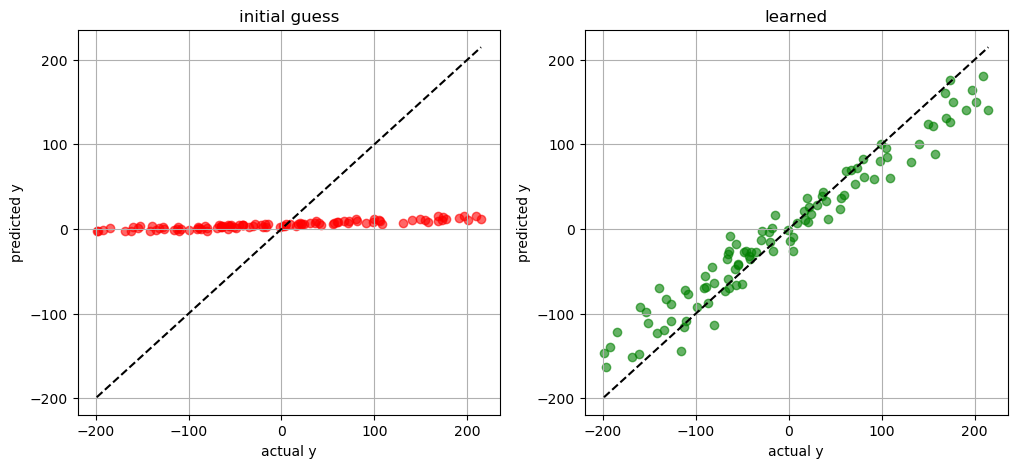

In [7]:
# predicted vs actual: points on the diagonal = perfect prediction
x1 = x[:, 0].numpy()
x2 = x[:, 1].numpy()
y_true = y.numpy().ravel()

pred_initial = 2.0 * x1 + 4.0 * x2 + 5.0                    # w1=2, w2=4, b=5
pred_learned = w1.item() * x1 + w2.item() * x2 + b.item()  # after training

# diagonal line y = x spanning the full value range
lo, hi = y_true.min(), y_true.max()

fig, (ax_i, ax_l) = plt.subplots(1, 2, figsize=(12, 5))

ax_i.scatter(y_true, pred_initial, color='red', alpha=0.6)
ax_i.plot([lo, hi], [lo, hi], 'k--')          # perfect-prediction line
ax_i.set_title('initial guess'); ax_i.set_xlabel('actual y'); ax_i.set_ylabel('predicted y')
ax_i.grid(True)

ax_l.scatter(y_true, pred_learned, color='green', alpha=0.6)
ax_l.plot([lo, hi], [lo, hi], 'k--')
ax_l.set_title('learned'); ax_l.set_xlabel('actual y'); ax_l.set_ylabel('predicted y')
ax_l.grid(True)

plt.show()

In [8]:
# movable 3D: drag to rotate. red = initial plane, green = learned plane
import plotly.graph_objects as go

x1 = x[:, 0].numpy()
x2 = x[:, 1].numpy()
y_np = y.numpy().ravel()

x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 10),
    np.linspace(x2.min(), x2.max(), 10),
)
initial_plane = 2.0 * x1_grid + 4.0 * x2_grid + 5.0
learned_plane = w1.item() * x1_grid + w2.item() * x2_grid + b.item()

fig = go.Figure()
fig.add_scatter3d(x=x1, y=x2, z=y_np, mode='markers',
                  marker=dict(size=3, color='blue'), name='data')
fig.add_surface(x=x1_grid, y=x2_grid, z=initial_plane, opacity=0.5,
                showscale=False, colorscale='Reds', name='initial')
fig.add_surface(x=x1_grid, y=x2_grid, z=learned_plane, opacity=0.5,
                showscale=False, colorscale='Greens', name='learned')
fig.update_layout(scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='y'))
fig.show()